In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs

In [2]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=[10, 15, 20], n_features=2, centers=[[-1, -1], [0, 1], [1, 0]])

X, y

(array([[ 0.60293129, -0.17140988],
        [-1.51551147, -1.76439357],
        [-0.22924999, -1.07116675],
        [ 2.88367277, -1.22097146],
        [ 1.11476517,  2.09202962],
        [-0.53453409, -0.92536806],
        [ 0.91918631,  3.02051325],
        [-0.84814823,  1.65943101],
        [-0.22567779, -0.0054542 ],
        [-0.36157938,  1.70398067],
        [ 0.57306658,  0.31164201],
        [ 2.40250962,  0.33310016],
        [ 2.39288989,  0.46199186],
        [ 2.60498103,  1.57407006],
        [-0.44396533,  0.84703502],
        [-2.08349991, -0.7938643 ],
        [ 0.68562293,  1.73347207],
        [ 0.04135898,  0.35232222],
        [-0.78537844,  3.01815602],
        [-0.20938109, -1.09256078],
        [-0.63851137,  0.9514683 ],
        [-1.96558304, -1.69301002],
        [-1.2770693 , -0.42773445],
        [-1.64333813,  2.11511151],
        [-0.33798048,  1.62172701],
        [ 0.13208599,  0.23828024],
        [ 1.69123165,  0.6722576 ],
        [-0.65052777, -1.385

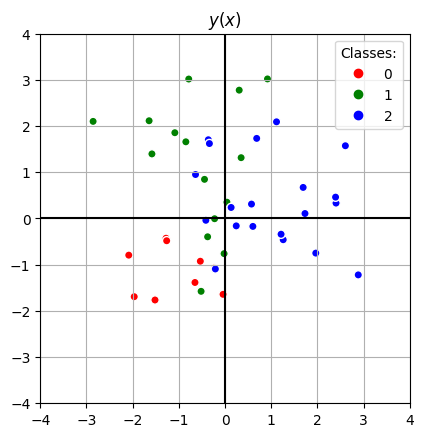

In [3]:
from  matplotlib.colors import ListedColormap
rgb_map = ListedColormap(('r', 'g', 'b'))

plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.legend(*plt.scatter(X[:, 0], X[:, 1], c=y, cmap=rgb_map, edgecolors='w').legend_elements(), title='Classes:')
plt.title('$y(x)$')
plt.axis('square'); plt.axis((-4.0, 4.0, -4.0, 4.0))
plt.show()

In [24]:
class KNearestNeighbors:
    
    def __init__(self, k):
        self.k = k
        self.classes = None
        
    def __repr__(self):
        return f'KNearestNeighbors(k={repr(self.k)})'
        
    def fit(self,X, y):
        self.classes = np.unique(y)
        self.X_train = X
        self.y_train = y
        return self

    def predict_proba(self,X):
        y_probas = []
        for instance in X: 
            # calculate all distance from instace to everything in X_train
            distances2 = []
            for point in self.X_train:
                d2 = sum((x1-x2)**2 for x1 ,x2 in zip(instance,point))
                distances2.append(d2)
            distances2 = np.array(distances2)
            # sort the distances and determine the distance of the k'th smallest one
            threshold = sorted(distances2)[self.k - 1]
            # calcualte the distribution of class labels among neighbors with distance <= threshold
            neighbor_labels =self.y_train[distances2 <= threshold]
            # neighbors_labels = [2, 2, 1,1,2] -> [0.0, 0.4, 0.6]
            y_onehot = (np.array([neighbor_labels]).T == self. classes)
            probabilities = np.mean(y_onehot,axis=0)
            y_probas.append(probabilities)
        y_probas = np.array(y_probas)
        return y_probas
        
    def predict(self, X):
        yhat = self.classes[np.argmax(self.predict_proba(X), axis=1)]
        return yhat

In [28]:
model = KNearestNeighbors(k=1)
model.fit(X,y)
y_pred = model.predict_proba(X)
y_pred

array([[0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.]])

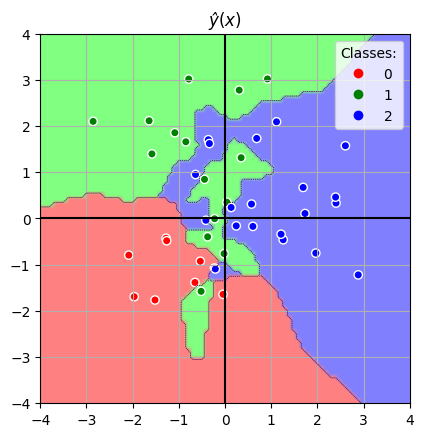

In [29]:
xx1, xx2 = np.meshgrid(np.linspace(-4.0, 4.0, 81), np.linspace(-4.0, 4.0, 81))
XX = np.array([xx1.ravel(), xx2.ravel()]).T
yy = model.predict_proba(XX).reshape(xx1.shape + (3, ))

plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.imshow(yy, extent=(-4.0, 4.0, -4.0, 4.0), origin='lower', interpolation='bilinear', alpha=0.5)
for z in range(yy.shape[2]):
    plt.contour(xx1, xx2, yy[:, :, z] / (1.0 - yy.min(axis=2)), [0.5], linewidths=0.5, linestyles='dotted')
plt.legend(*plt.scatter(X[:, 0], X[:, 1], c=y, cmap=rgb_map, edgecolors='w').legend_elements(), title='Classes:')
plt.title('$ŷ(x)$')
plt.axis('square'); plt.axis((-4.0, 4.0, -4.0, 4.0))
plt.show()

In [ ]:
# data augmentation

In [35]:
# SMOT
n_per_class = 50
k = 3
X_aug = []
y_aug = []

classes, counts = np.unique(y, return_counts = True)
for class_, count in zip(classes,counts):
    X_fromclass = X[y == class_,:]
    y_fromclass = X[y == class_]
    for _ in range(n_per_class - count):
        index1 = np.random.choice(np.arange(X_fromclass.shape[0]))
        instance = X_fromclass[index1,:]
        distances2 = []
        for point in X_fromclass:
            d2 = sum((x1-x2)**2 for x1 ,x2 in zip(instance,point))
            distances2.append(d2)
        distances2 = np.array(distances2)
        threshold = sorted(distances2)[k]
        X_neighbor =X_fromclass[np.logical_and(0.0<distances2,distances2<= threshold)]
        index2 = np.random.choice(np.arange(k))
        neighbor = X_neighbor[index2,:]
        fraction = np.random.rand()
        new_point = fraction * instance +(1-fraction) * neighbor
        X_aug.append(new_point)
        y_aug.append(class_)
        
X_total = np.concatenate((X, X_aug))
y_total = np.concatenate((y, y_aug))

X_total.shape

(150, 2)

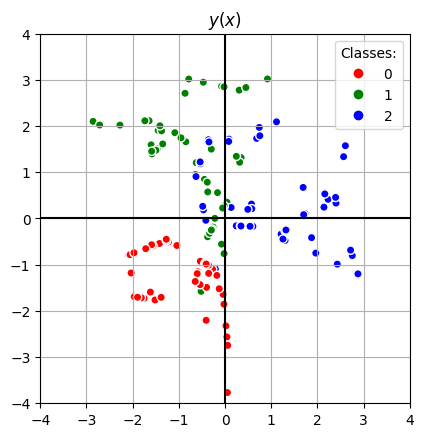

In [36]:
from  matplotlib.colors import ListedColormap
rgb_map = ListedColormap(('r', 'g', 'b'))

plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.legend(*plt.scatter(X_total[:, 0], X_total[:, 1], c=y_total, cmap=rgb_map, edgecolors='w').legend_elements(), title='Classes:')
plt.title('$y(x)$')
plt.axis('square'); plt.axis((-4.0, 4.0, -4.0, 4.0))
plt.show()